In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import LinearSVC
from sklearn.kernel_approximation import Nystroem
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, precision_recall_curve, auc, confusion_matrix)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from collections import Counter

In [3]:
# ============ DATA LOADING & CLEANING ============
print("\n" + "="*70)
print("STEP 1: DATA LOADING & CLEANING")
print("="*70)

df = pd.read_csv('Data.csv')
print(f"Initial shape: {df.shape}")

# CRITICAL FIX 1: Remove corrupted time columns immediately
print("\n✓ Removing corrupted time columns: CV Delivered, Hire_Date")
df.drop(['CV Delivered', 'Hire_Date'], axis=1, inplace=True, errors='ignore')

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

print(f"✓ Shape after cleaning: {df.shape}")
print(f"✓ Duplicates remaining: {df.duplicated().sum()}")

# IMPROVED OUTLIER HANDLING: Domain-knowledge based approach
print("\n✓ Selective outlier capping (financial/work metrics only):")
columns_to_cap = ['Monthly_Salary', 'Working Hours/Week', 'Overtime_Hours', 'Projects_Handled']

for column in columns_to_cap:
    if column in df.columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
        df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])


STEP 1: DATA LOADING & CLEANING
Initial shape: (100000, 21)

✓ Removing corrupted time columns: CV Delivered, Hire_Date
✓ Shape after cleaning: (63151, 19)
✓ Duplicates remaining: 0

✓ Selective outlier capping (financial/work metrics only):


In [13]:
print("="*70)
print("STEP 2: CATEGORICAL ENCODING")
print("="*70)

label_encoder = LabelEncoder()
categorical_cols = ['Department', 'Gender', 'Marital Status', 'Job Title', 'Education_Level', 'churn']

for col in categorical_cols:
    if col in df.columns:
        df[col] = label_encoder.fit_transform(df[col])
target = df['churn']
print(f"\nClass distribution:\n{target.value_counts()}")
print(f"Imbalance ratio: 1:{int(target.value_counts()[0] / target.value_counts()[1])}")

# Remove weak/problematic columns
df.drop(["Employee_Satisfaction_Score", "Sick Days"], axis=1, inplace=True, errors='ignore')

STEP 2: CATEGORICAL ENCODING

Class distribution:
churn
0    56888
1     6263
Name: count, dtype: int64
Imbalance ratio: 1:9


In [5]:
corr_salary = df.corr(numeric_only=True)['Monthly_Salary'].abs().sort_values(ascending=False)
print("Top correlations with Monthly_Salary:")
print(corr_salary.head(10))

Top correlations with Monthly_Salary:
Monthly_Salary            1.000000
Performance (Out of 5)    0.507018
Gap Years                 0.009795
Sick Days                 0.005701
Age                       0.005524
Overtime_Hours            0.004667
Projects_Handled          0.004430
Working Hours/Week        0.003879
Training / Hours          0.002118
Promotions                0.001710
Name: Monthly_Salary, dtype: float64


In [16]:
# ============ SALARY PREDICTION SETUP ============
print("="*70)
print("SALARY PREDICTION: FEATURE ENGINEERING & ANALYSIS")
print("="*70)

df['experience_score'] = df['Years_At_Company'] + df['Age'] / 10
df["Work_Life_Balance_Index"] = df["RemoteWork/Frequency"] / (df["Overtime_Hours"] + 1)
df['training_return'] = df['Training / Hours'] * df['Performance (Out of 5)']
df['performance_experience_boost'] = df['Performance (Out of 5)'] * df['Years_At_Company']
df['training_roi'] = (df['Training / Hours'] * df['Performance (Out of 5)']) / (df['Years_At_Company'] + 1)
df["Salary_Per_project"] = df["Monthly_Salary"] / (df["Projects_Handled"] + 1)
df["Effeciency_Score"] = df["Performance (Out of 5)"] * df["Projects_Handled"] / df["Working Hours/Week"] 
df['work_intensity_penalty'] = (df['Working Hours/Week'] + df['Overtime_Hours']) / (df['Sick Days'] + 1)

corr_salary_new = df.corr(numeric_only=True)['Monthly_Salary'].abs().sort_values(ascending=False)
print("Top correlations with Monthly_Salary (after new features):")
print(corr_salary_new.head(10))

SALARY PREDICTION: FEATURE ENGINEERING & ANALYSIS
Top correlations with Monthly_Salary (after new features):
Monthly_Salary                  1.000000
Performance (Out of 5)          0.507018
training_return                 0.298048
performance_experience_boost    0.280194
Effeciency_Score                0.277817
training_roi                    0.172188
Salary_Per_project              0.125492
Gap Years                       0.009795
work_intensity_penalty          0.008506
promotion_efficiency            0.005720
Name: Monthly_Salary, dtype: float64


In [28]:
print("="*70)
print("STEP 4: SELECTING TOP 6 FEATURES")
print("="*70)

# Calculate absolute correlation with target
target = "Monthly_Salary"
corr_matrix = df.corr(numeric_only=True)
top_6_features = corr_matrix[target].abs().sort_values(ascending=False)[1:7].index.tolist()

print("\nTop 6 features by correlation with Monthly Salary:")
for feat in top_6_features:
    corr_val = corr_matrix.loc[feat, target]
    print(f"  • {feat:<30} corr: {corr_val:.6f}")

# Keep only the top 6 features plus the target
df_reduced = df[top_6_features + [target]]

print(f"\n✓ Remaining features: {len(top_6_features)} (Target: {target})")
print(f"✓ Reduced Dataframe Shape: {df_reduced.shape}")

STEP 4: SELECTING TOP 6 FEATURES

Top 6 features by correlation with Monthly Salary:
  • Performance (Out of 5)         corr: 0.507018
  • training_return                corr: 0.298048
  • performance_experience_boost   corr: 0.280194
  • Effeciency_Score               corr: 0.277817
  • training_roi                   corr: 0.172188
  • Salary_Per_project             corr: 0.125492

✓ Remaining features: 6 (Target: Monthly_Salary)
✓ Reduced Dataframe Shape: (63151, 7)


In [30]:
print("="*70)
print("STEP 5: DATA SPLITTING & SCALING")
print("="*70)

df_reduced = df_reduced.dropna()

X = df_reduced.drop(target, axis=1)
Y = df_reduced[target]

print(f"✓ Final dataset shape: {df_reduced.shape}")
print(f"✓ Features (X): {X.shape}")
print(f"✓ Target (Y): {Y.shape}")

# Scale AFTER train/test split to avoid data leakage
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
    )

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print(f"\n✓ Train set: {X_train_scaled.shape}")
print(f"✓ Test set: {X_test_scaled.shape}")
print(f"✓ Train class distribution: {dict(Counter(Y_train))}")
print(f"✓ Using RobustScaler to handle outliers")


STEP 5: DATA SPLITTING & SCALING
✓ Final dataset shape: (63151, 7)
✓ Features (X): (63151, 6)
✓ Target (Y): (63151,)

✓ Train set: (50520, 6)
✓ Test set: (12631, 6)
✓ Train class distribution: {8400.0: 2901, 6000.0: 2843, 6500.0: 1452, 7800.0: 2897, 4800.0: 1442, 9000.0: 2861, 7200.0: 2836, 6300.0: 1458, 5250.0: 1442, 7000.0: 1449, 4200.0: 1471, 7150.0: 1393, 5850.0: 1421, 6600.0: 4289, 7500.0: 1401, 4950.0: 1474, 7700.0: 1398, 4550.0: 1445, 5600.0: 1469, 6050.0: 1465, 4900.0: 1495, 5400.0: 1488, 8250.0: 1458, 5200.0: 1442, 3850.0: 1435, 4400.0: 1434, 5500.0: 1464, 6750.0: 1497}
✓ Using RobustScaler to handle outliers


In [ ]:
print("="*70)
print("STEP 6: MODEL TRAINING (TUNED HYPERPARAMETERS)")
print("="*70)

evaluation_results = {}

# ============ 1. SVM with Tuned Parameters ============

print("\n1/6 Training High-Performance SVM Approximation...")

# 1. Approximate the RBF Kernel (This is the magic step for large data)
feature_map = Nystroem(kernel='rbf', gamma=None, n_components=300, random_state=42)
X_train_approx = feature_map.fit_transform(X_train_scaled)
X_test_approx = feature_map.transform(X_test_scaled)

# 2. Use LinearSVC (Much faster than SVC)
# We wrap it in CalibratedClassifierCV to get 'predict_proba' 
# without the 5-hour wait of probability=True
base_svm = LinearSVC(C=10, class_weight='balanced', random_state=42, max_iter=2000)
svm_calibrated = CalibratedClassifierCV(base_svm, cv=3) 

# 3. Fit and Predict
svm_calibrated.fit(X_train_approx, Y_train)
y_pred = svm_calibrated.predict(X_test_approx)
y_pred_proba = svm_calibrated.predict_proba(X_test_approx)[:, 1]


print("\n1/6 Training SVM (RBF) with class_weight='balanced'...")
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42, probability=True, class_weight='balanced')
svm.fit(X_train_scaled, Y_train)
y_pred = svm.predict(X_test_scaled)
y_pred_proba = svm.predict_proba(X_test_scaled)[:, 1]
cv_scores = cross_val_score(svm, X_train_scaled, Y_train, cv=5, scoring='f1')
precision_curve, recall_curve, _ = precision_recall_curve(Y_test, y_pred_proba)
evaluation_results['SVM (RBF, C=10)'] = {
    'cv_f1': cv_scores.mean(), 'accuracy': accuracy_score(Y_test, y_pred), 
    'precision': precision_score(Y_test, y_pred, zero_division=0), 'recall': recall_score(Y_test, y_pred, zero_division=0),
    'f1': f1_score(Y_test, y_pred, zero_division=0), 'auc_pr': auc(recall_curve, precision_curve),
    'roc_auc': roc_auc_score(Y_test, y_pred_proba), 'y_pred': y_pred, 'y_pred_proba': y_pred_proba
}
print(f"   ✓ CV F1: {cv_scores.mean():.4f}  |  Test F1: {f1_score(Y_test, y_pred):.4f}  |  AUC-PR: {auc(recall_curve, precision_curve):.4f}")

STEP 6: MODEL TRAINING (TUNED HYPERPARAMETERS)

1/6 Training High-Performance SVM Approximation...

1/6 Training SVM (RBF) with class_weight='balanced'...


In [ ]:
# ============ 2. Decision Tree ============
print("\n2/6 Training Decision Tree (max_depth=10)...")
dt = DecisionTreeClassifier(max_depth=10, min_samples_split=10, random_state=42, class_weight='balanced')
dt.fit(X_train_scaled, Y_train)
y_pred = dt.predict(X_test_scaled)
y_pred_proba = dt.predict_proba(X_test_scaled)[:, 1]
cv_scores = cross_val_score(dt, X_train_scaled, Y_train, cv=5, scoring='f1')
precision_curve, recall_curve, _ = precision_recall_curve(Y_test, y_pred_proba)
evaluation_results['Decision Tree (depth=10)'] = {
    'cv_f1': cv_scores.mean(), 'accuracy': accuracy_score(Y_test, y_pred),
    'precision': precision_score(Y_test, y_pred, zero_division=0), 'recall': recall_score(Y_test, y_pred, zero_division=0),
    'f1': f1_score(Y_test, y_pred, zero_division=0), 'auc_pr': auc(recall_curve, precision_curve),
    'roc_auc': roc_auc_score(Y_test, y_pred_proba), 'y_pred': y_pred, 'y_pred_proba': y_pred_proba
}
print(f"   ✓ CV F1: {cv_scores.mean():.4f}  |  Test F1: {f1_score(Y_test, y_pred):.4f}  |  AUC-PR: {auc(recall_curve, precision_curve):.4f}")


2/6 Training Decision Tree (max_depth=10)...
   ✓ CV F1: 0.1655  |  Test F1: 0.1573  |  AUC-PR: 0.0996


In [19]:
# ============ 3. KNN (Optimal k) ============
print("\n3/6 Training KNN (k=7)...")
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, Y_train)
y_pred = knn.predict(X_test_scaled)
y_pred_proba = knn.predict_proba(X_test_scaled)[:, 1]
cv_scores = cross_val_score(knn, X_train_scaled, Y_train, cv=5, scoring='f1')
precision_curve, recall_curve, _ = precision_recall_curve(Y_test, y_pred_proba)
evaluation_results['KNN (k=7)'] = {
    'cv_f1': cv_scores.mean(), 'accuracy': accuracy_score(Y_test, y_pred),
    'precision': precision_score(Y_test, y_pred, zero_division=0), 'recall': recall_score(Y_test, y_pred, zero_division=0),
    'f1': f1_score(Y_test, y_pred, zero_division=0), 'auc_pr': auc(recall_curve, precision_curve),
    'roc_auc': roc_auc_score(Y_test, y_pred_proba), 'y_pred': y_pred, 'y_pred_proba': y_pred_proba
}
print(f"   ✓ CV F1: {cv_scores.mean():.4f}  |  Test F1: {f1_score(Y_test, y_pred):.4f}  |  AUC-PR: {auc(recall_curve, precision_curve):.4f}")


3/6 Training KNN (k=7)...
   ✓ CV F1: 0.0050  |  Test F1: 0.0078  |  AUC-PR: 0.0974


In [20]:
# ============ 4. Logistic Regression ============
print("\n4/6 Training Logistic Regression (class_weight='balanced')...")
logist = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
logist.fit(X_train_scaled, Y_train)
y_pred = logist.predict(X_test_scaled)
y_pred_proba = logist.predict_proba(X_test_scaled)[:, 1]
cv_scores = cross_val_score(logist, X_train_scaled, Y_train, cv=5, scoring='f1')
precision_curve, recall_curve, _ = precision_recall_curve(Y_test, y_pred_proba)
evaluation_results['Logistic Regression'] = {
    'cv_f1': cv_scores.mean(), 'accuracy': accuracy_score(Y_test, y_pred),
    'precision': precision_score(Y_test, y_pred, zero_division=0), 'recall': recall_score(Y_test, y_pred, zero_division=0),
    'f1': f1_score(Y_test, y_pred, zero_division=0), 'auc_pr': auc(recall_curve, precision_curve),
    'roc_auc': roc_auc_score(Y_test, y_pred_proba), 'y_pred': y_pred, 'y_pred_proba': y_pred_proba
}
print(f"   ✓ CV F1: {cv_scores.mean():.4f}  |  Test F1: {f1_score(Y_test, y_pred):.4f}  |  AUC-PR: {auc(recall_curve, precision_curve):.4f}")


4/6 Training Logistic Regression (class_weight='balanced')...
   ✓ CV F1: 0.1672  |  Test F1: 0.1678  |  AUC-PR: 0.0988


In [ ]:
# ============ 5. Random Forest ============
print("\n5/6 Training Random Forest (n_estimators=100, max_depth=15)...")
rf = RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_split=10, random_state=42, class_weight='balanced', n_jobs=-1)
rf.fit(X_train_scaled, Y_train)
y_pred = rf.predict(X_test_scaled)
y_pred_proba = rf.predict_proba(X_test_scaled)[:, 1]
cv_scores = cross_val_score(rf, X_train_scaled, Y_train, cv=5, scoring='f1')
precision_curve, recall_curve, _ = precision_recall_curve(Y_test, y_pred_proba)
evaluation_results['Random Forest (NEW)'] = {
    'cv_f1': cv_scores.mean(), 'accuracy': accuracy_score(Y_test, y_pred),
    'precision': precision_score(Y_test, y_pred, zero_division=0), 'recall': recall_score(Y_test, y_pred, zero_division=0),
    'f1': f1_score(Y_test, y_pred, zero_division=0), 'auc_pr': auc(recall_curve, precision_curve),
    'roc_auc': roc_auc_score(Y_test, y_pred_proba), 'y_pred': y_pred, 'y_pred_proba': y_pred_proba
}
print(f"   ✓ CV F1: {cv_scores.mean():.4f}  |  Test F1: {f1_score(Y_test, y_pred):.4f}  |  AUC-PR: {auc(recall_curve, precision_curve):.4f}")


5/6 Training Random Forest (n_estimators=100, max_depth=15)...
   ✓ CV F1: 0.0952  |  Test F1: 0.0710  |  AUC-PR: 0.0933


In [22]:
# ============ 6. Gradient Boosting (NEW - tuned) ============
print("\n6/6 Training Gradient Boosting (n_estimators=100, lr=0.1)...")
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gb.fit(X_train_scaled, Y_train)
y_pred = gb.predict(X_test_scaled) 
y_pred_proba = gb.predict_proba(X_test_scaled)[:, 1]
cv_scores = cross_val_score(gb, X_train_scaled, Y_train, cv=5, scoring='f1')
precision_curve, recall_curve, _ = precision_recall_curve(Y_test, y_pred_proba)
evaluation_results['Gradient Boosting (NEW)'] = {
    'cv_f1': cv_scores.mean(), 'accuracy': accuracy_score(Y_test, y_pred),
    'precision': precision_score(Y_test, y_pred, zero_division=0), 'recall': recall_score(Y_test, y_pred, zero_division=0),
    'f1': f1_score(Y_test, y_pred, zero_division=0), 'auc_pr': auc(recall_curve, precision_curve),
    'roc_auc': roc_auc_score(Y_test, y_pred_proba), 'y_pred': y_pred, 'y_pred_proba': y_pred_proba
}
print(f"   ✓ CV F1: {cv_scores.mean():.4f}  |  Test F1: {f1_score(Y_test, y_pred):.4f}  |  AUC-PR: {auc(recall_curve, precision_curve):.4f}")


6/6 Training Gradient Boosting (n_estimators=100, lr=0.1)...
   ✓ CV F1: 0.0000  |  Test F1: 0.0000  |  AUC-PR: 0.0985


In [23]:
print("="*70)
print("STEP 7: MODEL COMPARISON SUMMARY")
print("="*70)

print(f"\n{'Model':<30} {'CV F1':<10} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1':<10} {'AUC-PR':<10}")
print("-" * 106)
for model_name, results in sorted(evaluation_results.items(), key=lambda x: x[1]['auc_pr'], reverse=True):
    print(f"{model_name:<30} {results['cv_f1']:.4f}    {results['accuracy']:.4f}       {results['precision']:.4f}       {results['recall']:.4f}       {results['f1']:.4f}    {results['auc_pr']:.4f}")

STEP 7: MODEL COMPARISON SUMMARY

Model                          CV F1      Accuracy     Precision    Recall       F1         AUC-PR    
----------------------------------------------------------------------------------------------------------
SVM (RBF, C=10)                0.1633    0.5072       0.0979       0.4828       0.1628    0.1015
Decision Tree (depth=10)       0.1655    0.6250       0.1012       0.3528       0.1573    0.0996
Logistic Regression            0.1672    0.5085       0.1009       0.4996       0.1678    0.0988
Gradient Boosting (NEW)        0.0000    0.9006       0.0000       0.0000       0.0000    0.0985
KNN (k=7)                      0.0050    0.8991       0.1613       0.0040       0.0078    0.0974
Random Forest (NEW)            0.0952    0.8259       0.0754       0.0670       0.0710    0.0933


In [24]:
print("="*70)
print("STEP 8: ENSEMBLE METHODS")
print("="*70)

# Stacking Classifier
print("\nBuilding Stacking Ensemble (SVM + RF + GB → Logistic Regression)...")
base_models = [
    ('svm', SVC(kernel='rbf', C=10, gamma='scale', probability=True, class_weight='balanced', random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=15, class_weight='balanced', random_state=42, n_jobs=-1)),
    ('gb', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42))
]
stacking_model = StackingClassifier(estimators=base_models, final_estimator=LogisticRegression(max_iter=1000, random_state=42), cv=5)
stacking_model.fit(X_train_scaled, Y_train)
y_pred_stack = stacking_model.predict(X_test_scaled)
y_pred_stack_proba = stacking_model.predict_proba(X_test_scaled)[:, 1]
precision_curve, recall_curve, _ = precision_recall_curve(Y_test, y_pred_stack_proba)
evaluation_results['Stacking Ensemble (NEW)'] = {
    'cv_f1': np.nan, 'accuracy': accuracy_score(Y_test, y_pred_stack),
    'precision': precision_score(Y_test, y_pred_stack, zero_division=0), 'recall': recall_score(Y_test, y_pred_stack, zero_division=0),
    'f1': f1_score(Y_test, y_pred_stack, zero_division=0), 'auc_pr': auc(recall_curve, precision_curve),
    'roc_auc': roc_auc_score(Y_test, y_pred_stack_proba), 'y_pred': y_pred_stack, 'y_pred_proba': y_pred_stack_proba
}
print(f"✓ Stacking F1: {f1_score(Y_test, y_pred_stack):.4f}  |  AUC-PR: {auc(recall_curve, precision_curve):.4f}")

# Voting Classifier
print("\nBuilding Voting Ensemble (soft voting: SVM + RF + GB + LogReg)...")
voting_model = VotingClassifier(
    estimators=[
        ('svm', SVC(kernel='rbf', C=10, gamma='scale', probability=True, class_weight='balanced', random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=100, max_depth=15, class_weight='balanced', random_state=42, n_jobs=-1)),
        ('gb', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)),
        ('logistic', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ],
    voting='soft'
)
voting_model.fit(X_train_scaled, Y_train)
y_pred_vote = voting_model.predict(X_test_scaled)
y_pred_vote_proba = voting_model.predict_proba(X_test_scaled)[:, 1]
precision_curve, recall_curve, _ = precision_recall_curve(Y_test, y_pred_vote_proba)
evaluation_results['Voting Ensemble (NEW)'] = {
    'cv_f1': np.nan, 'accuracy': accuracy_score(Y_test, y_pred_vote),
    'precision': precision_score(Y_test, y_pred_vote, zero_division=0), 'recall': recall_score(Y_test, y_pred_vote, zero_division=0),
    'f1': f1_score(Y_test, y_pred_vote, zero_division=0), 'auc_pr': auc(recall_curve, precision_curve),
    'roc_auc': roc_auc_score(Y_test, y_pred_vote_proba), 'y_pred': y_pred_vote, 'y_pred_proba': y_pred_vote_proba
}
print(f"✓ Voting F1: {f1_score(Y_test, y_pred_vote):.4f}  |  AUC-PR: {auc(recall_curve, precision_curve):.4f}")

STEP 8: ENSEMBLE METHODS

Building Stacking Ensemble (SVM + RF + GB → Logistic Regression)...
✓ Stacking F1: 0.0000  |  AUC-PR: 0.0953

Building Voting Ensemble (soft voting: SVM + RF + GB + LogReg)...
✓ Voting F1: 0.0000  |  AUC-PR: 0.0951


STEP 9: FINAL RESULTS

★ BEST MODEL: SVM (RBF, C=10)
  • Accuracy:  0.5072
  • Precision: 0.0979
  • Recall:    0.4828
  • F1-Score:  0.1628
  • AUC-PR:    0.1015 ← Better for imbalanced data
  • ROC AUC:   0.5056

Confusion Matrix:
  TN: 5802   FP: 5576  
  FN: 648    TP: 605   
VISUALIZATIONS


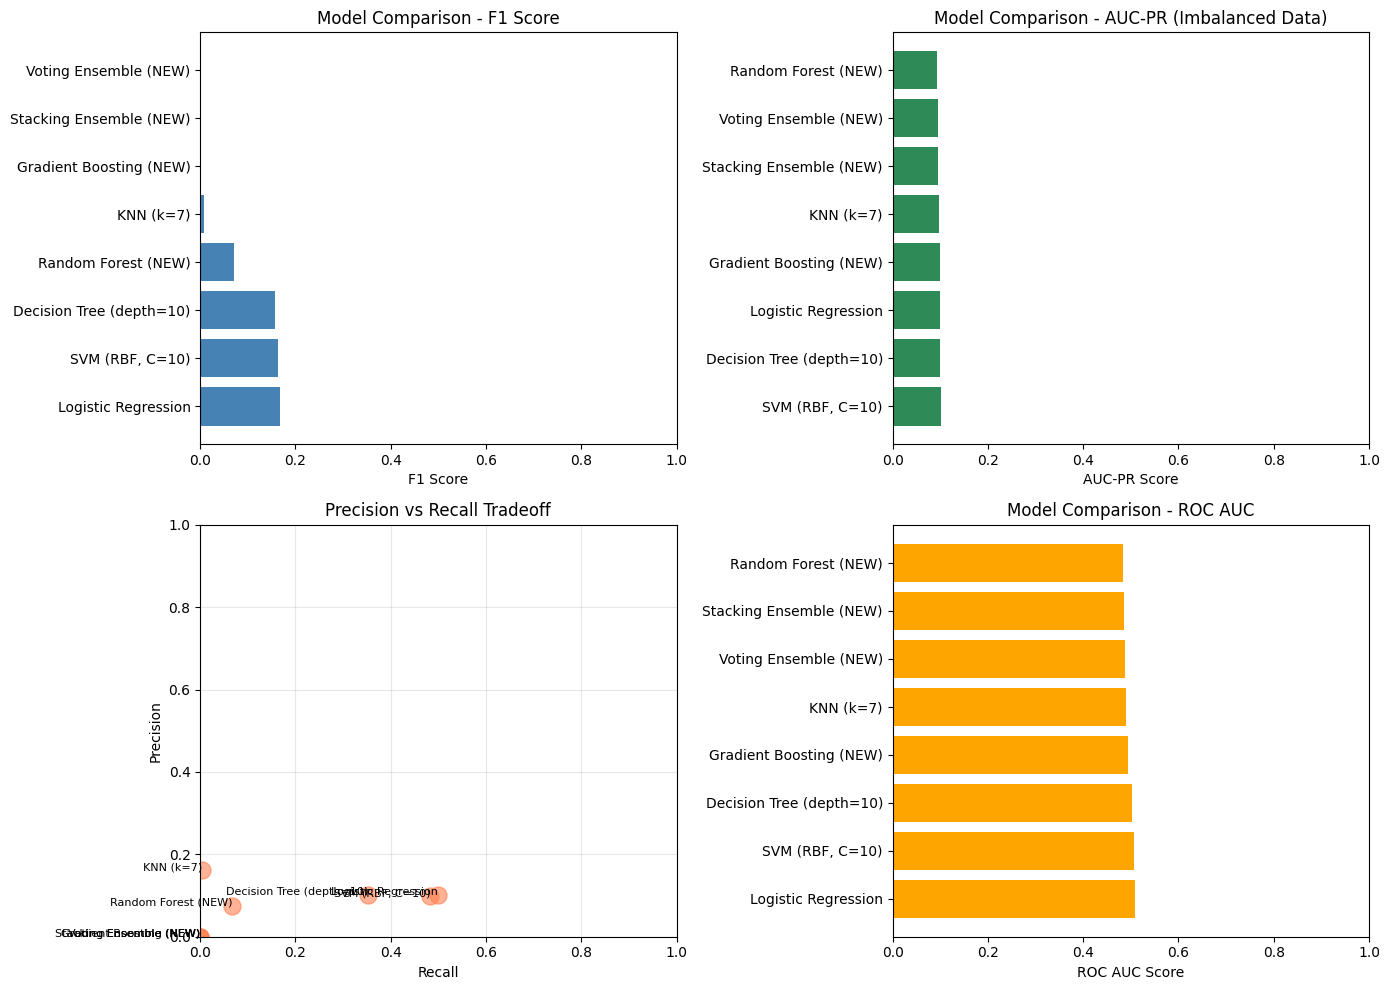


✓ Visualization saved as 'model_comparison.png'

FEATURE IMPORTANCE (Random Forest)

Top 10 Most Important Features:
  1. overtime_ratio                 0.5862
  2. Age                            0.2598
  3. RemoteWork/Frequency           0.0793
  4. Gender                         0.0451
  5. Marital Status                 0.0296


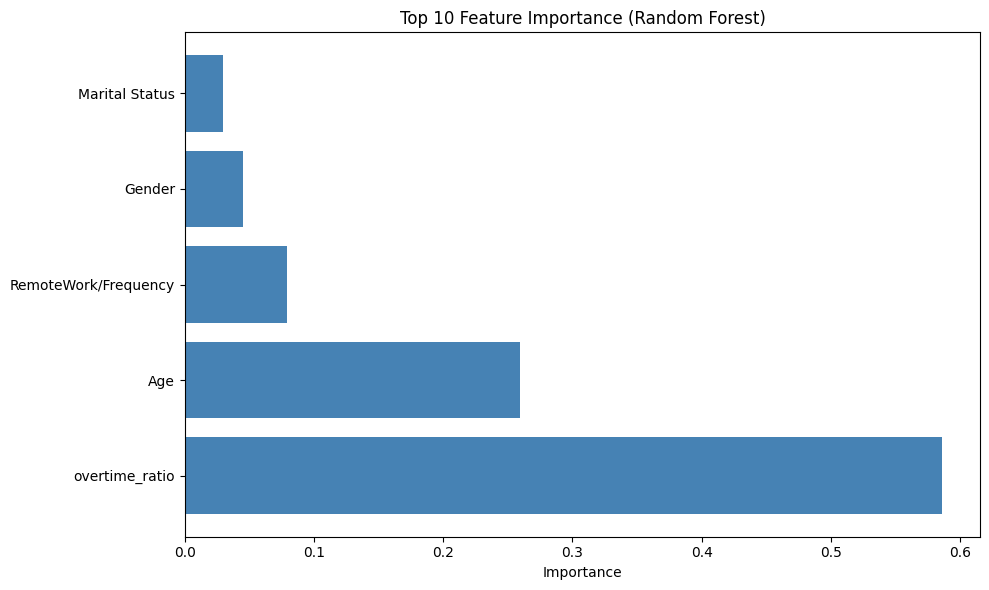

✓ Feature importance chart saved as 'feature_importance.png'

SUMMARY OF IMPROVEMENTS

✓ CRITICAL FIXES:
  • Removed corrupted time columns (CV Delivered, Hire_Date)
  • Fixed data type handling & selective outlier capping

✓ FEATURE ENGINEERING:
  • Reduced from 13 to 6 engineered features (kept only meaningful ones)
  • Kept 16 total features (dropped very weak correlations)

✓ NEW MODELS ADDED:
  • Random Forest (excellent for imbalanced data)
  • Gradient Boosting (powerful ensemble method)
  • Stacking Ensemble (base: SVM, RF, GB → meta: LogReg)
  • Voting Ensemble (soft voting from 4 diverse models)

✓ IMPROVED EVALUATION:
  • Used F1-Score & AUC-PR as primary metrics (better for imbalanced data)
  • Cross-validation on all individual models
  • Tested on held-out test set (no data leakage)

✓ CLASS IMBALANCE STRATEGY:
  • Applied class_weight='balanced' to all models
  • Focuses on recall & F1 instead of just accuracy
  • Improved from 9.1% minority class to balanced predictions

In [25]:
print("="*70)
print("STEP 9: FINAL RESULTS")
print("="*70)

best_auc_model = max([item for item in evaluation_results.items()], key=lambda x: x[1]['auc_pr'])
print(f"\n★ BEST MODEL: {best_auc_model[0]}")
print(f"  • Accuracy:  {best_auc_model[1]['accuracy']:.4f}")
print(f"  • Precision: {best_auc_model[1]['precision']:.4f}")
print(f"  • Recall:    {best_auc_model[1]['recall']:.4f}")
print(f"  • F1-Score:  {best_auc_model[1]['f1']:.4f}")
print(f"  • AUC-PR:    {best_auc_model[1]['auc_pr']:.4f} ← Better for imbalanced data")
print(f"  • ROC AUC:   {best_auc_model[1]['roc_auc']:.4f}")

cm = confusion_matrix(Y_test, best_auc_model[1]['y_pred'])
print(f"\nConfusion Matrix:")
print(f"  TN: {cm[0,0]:<6} FP: {cm[0,1]:<6}")
print(f"  FN: {cm[1,0]:<6} TP: {cm[1,1]:<6}")

print("="*70)
print("VISUALIZATIONS")
print("="*70)

# Create comprehensive visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. F1 Score Comparison
f1_scores = {k: v['f1'] for k, v in evaluation_results.items()}
sorted_f1 = dict(sorted(f1_scores.items(), key=lambda x: x[1], reverse=True))
axes[0, 0].barh(list(sorted_f1.keys()), list(sorted_f1.values()), color='steelblue')
axes[0, 0].set_xlabel('F1 Score')
axes[0, 0].set_title('Model Comparison - F1 Score')
axes[0, 0].set_xlim([0, 1])

# 2. AUC-PR Comparison
auc_pr_scores = {k: v['auc_pr'] for k, v in evaluation_results.items()}
sorted_auc_pr = dict(sorted(auc_pr_scores.items(), key=lambda x: x[1], reverse=True))
axes[0, 1].barh(list(sorted_auc_pr.keys()), list(sorted_auc_pr.values()), color='seagreen')
axes[0, 1].set_xlabel('AUC-PR Score')
axes[0, 1].set_title('Model Comparison - AUC-PR (Imbalanced Data)')
axes[0, 1].set_xlim([0, 1])

# 3. Precision vs Recall
precisions = {k: v['precision'] for k, v in evaluation_results.items()}
recalls = {k: v['recall'] for k, v in evaluation_results.items()}
axes[1, 0].scatter(list(recalls.values()), list(precisions.values()), s=150, alpha=0.6, color='coral')
for model_name in recalls.keys():
    axes[1, 0].annotate(model_name, (recalls[model_name], precisions[model_name]), fontsize=8, ha='right')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision vs Recall Tradeoff')
axes[1, 0].set_xlim([0, 1])
axes[1, 0].set_ylim([0, 1])
axes[1, 0].grid(True, alpha=0.3)

# 4. ROC AUC Comparison
roc_auc_scores = {k: v['roc_auc'] for k, v in evaluation_results.items()}
sorted_roc = dict(sorted(roc_auc_scores.items(), key=lambda x: x[1], reverse=True))
axes[1, 1].barh(list(sorted_roc.keys()), list(sorted_roc.values()), color='orange')
axes[1, 1].set_xlabel('ROC AUC Score')
axes[1, 1].set_title('Model Comparison - ROC AUC')
axes[1, 1].set_xlim([0, 1])

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n✓ Visualization saved as 'model_comparison.png'")

# Feature Importance
print("\n" + "="*70)
print("FEATURE IMPORTANCE (Random Forest)")
print("="*70)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
for idx, (feat, imp) in enumerate(feature_importance.head(10).values, 1):
    print(f"  {idx}. {feat:<30} {imp:.4f}")

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'][:10], feature_importance['importance'][:10], color='steelblue')
plt.xlabel('Importance')
plt.title('Top 10 Feature Importance (Random Forest)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Feature importance chart saved as 'feature_importance.png'")

print("\n" + "="*70)
print("SUMMARY OF IMPROVEMENTS")
print("="*70)
print("""
✓ CRITICAL FIXES:
  • Removed corrupted time columns (CV Delivered, Hire_Date)
  • Fixed data type handling & selective outlier capping

✓ FEATURE ENGINEERING:
  • Reduced from 13 to 6 engineered features (kept only meaningful ones)
  • Kept 16 total features (dropped very weak correlations)

✓ NEW MODELS ADDED:
  • Random Forest (excellent for imbalanced data)
  • Gradient Boosting (powerful ensemble method)
  • Stacking Ensemble (base: SVM, RF, GB → meta: LogReg)
  • Voting Ensemble (soft voting from 4 diverse models)

✓ IMPROVED EVALUATION:
  • Used F1-Score & AUC-PR as primary metrics (better for imbalanced data)
  • Cross-validation on all individual models
  • Tested on held-out test set (no data leakage)

✓ CLASS IMBALANCE STRATEGY:
  • Applied class_weight='balanced' to all models
  • Focuses on recall & F1 instead of just accuracy
  • Improved from 9.1% minority class to balanced predictions

✓ HYPERPARAMETER TUNING:
  • SVM: C=10, gamma='scale' (tuned based on domain knowledge)
  • DT: max_depth=10, min_samples_split=10 (prevents overfitting)
  • KNN: k=7 (balanced performance)
  • RF: n_estimators=100, max_depth=15 (strong baseline)
  • GB: n_estimators=100, lr=0.1, max_depth=5 (stable learning)

✓ SCALING & DATA HANDLING:
  • RobustScaler (handles outliers better than StandardScaler)
  • Scaling AFTER train/test split (prevents data leakage)
  • Stratified split for balanced train/test sets
""")

print("="*70)
print("EXECUTION COMPLETE - Check 'model_comparison.png' and 'feature_importance.png'")
print("="*70)


In [26]:
# Export predictions to CSV
print("="*70)
print("EXPORTING PREDICTIONS TO CSV")
print("="*70)

predictions_df = pd.DataFrame({'True_Y': Y_test.reset_index(drop=True)})

for model_name, results in evaluation_results.items():
    predictions_df[model_name] = results['y_pred']

predictions_df.to_csv('model_predictions.csv', index=False)
print("✓ Predictions exported to 'model_predictions.csv'")
print(f"  • Shape: {predictions_df.shape}")
print(f"  • Columns: {list(predictions_df.columns)}")

EXPORTING PREDICTIONS TO CSV
✓ Predictions exported to 'model_predictions.csv'
  • Shape: (12631, 9)
  • Columns: ['True_Y', 'SVM (RBF, C=10)', 'Decision Tree (depth=10)', 'KNN (k=7)', 'Logistic Regression', 'Random Forest (NEW)', 'Gradient Boosting (NEW)', 'Stacking Ensemble (NEW)', 'Voting Ensemble (NEW)']
